#### 05 · Multi-Target Price Forecasting
Forecast next month's **Min / Avg / Max price** per product.

**Flow:** Setup → Split → Baseline → Random Forest (Optuna) → LightGBM (Optuna) → Validation comparison → Final Test/Forecast.

Error analysis (category/unit/volatility/SHAP) is done in a **separate notebook** using `results/validation_month_9_predictions.csv` and `results/month_11_forecast.csv`.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import lightgbm as lgb

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

RANDOM_STATE = 42
N_TRIALS = 50

os.makedirs("results", exist_ok=True)
os.makedirs("plots", exist_ok=True)

/Users/bruker/Desktop/Multi-Target Price Forecasting /.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load cleaned dataset
data_path = "data/all_months_features.csv"
if not os.path.exists(data_path):
    raise FileNotFoundError(f"File not found: {data_path}")

df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
print(f"Number of products: {df['Product_Name'].nunique()}")

Dataset shape: (798, 77)
Number of products: 95


In [3]:
##  Month Index & Next-Month Targets
# Keep the original BS-calendar month position (1-10) for reference/reporting,
# then build a per-product LOCAL sequence index (1, 2, 3...) — this is what the
# lag/rolling features and the train/valid/forecast split are based on, since
# products are not observed in the same set of calendar months.
df = df.sort_values(["Product_Name", "month_idx"]).reset_index(drop=True)
df["calendar_month_idx"] = df["month_idx"]                     # 1-10, real BS month position
df["month_idx"] = df.groupby("Product_Name").cumcount() + 1     # 1..n, this product's own history
df = df.sort_values(["Product_Name", "month_idx"]).reset_index(drop=True)

# Targets = next month's Min/Avg/Max price (shift -1 within each product)
targets_base = ["Min_Price", "Avg_Price", "Max_Price"]
targets_next = ["Min_Price_next", "Avg_Price_next", "Max_Price_next"]
for base, nxt in zip(targets_base, targets_next):
    df[nxt] = df.groupby("Product_Name")[base].shift(-1)

print(df.groupby("month_idx")["Product_Name"].nunique().to_string())


month_idx
1     95
2     91
3     90
4     89
5     85
6     83
7     80
8     71
9     64
10    50


#####  Time-Based Split (Per-Product Local Sequence)
- **Train:** each product's own local months 1–8 (its own observed history, not global calendar alignment)
- **Validation:** each product's own local month 9 → predicts local month 10 (used to pick the best model)
- **Forecast input:** **every product's own most recent observed row** → predicts that product's next month

The panel is unbalanced — many products are observed in only a handful of the
10 BS months (e.g. only months 5–6). Filtering the forecast input on a single
global month number (the old `month_idx == 10`) silently excluded every
product that never reached that many observations. Using each product's own
**last row** instead means every product gets a forecast, without
forward-filling or fabricating any data — sparse products simply forecast
their own next real month rather than a shared "month 11".


In [4]:
train_df = df[df["month_idx"] <= 8].dropna(subset=targets_next).copy()
valid_df = df[df["month_idx"] == 9].dropna(subset=targets_next).copy()

# --- Forecast input: EVERY product's own most recent observed row ---
# No forward-filling, no fabricated rows: we simply forecast one step ahead
# from whatever real data each product actually has.
test_df = (
    df.sort_values(["Product_Name", "month_idx"])
      .groupby("Product_Name", as_index=False)
      .tail(1)
      .copy()
)

print(f"Training   (local months 1-8) : {len(train_df)}")
print(f"Validation (local month 9)    : {len(valid_df)}  (target = local month 10)")
print(f"Forecast input (per-product)  : {len(test_df)}  "
      f"({test_df['Product_Name'].nunique()} / {df['Product_Name'].nunique()} products — full coverage)")
print(f"  Full 10-month history : {(test_df['n_months_present'] == 10).sum()} products")
print(f"  Partial history       : {(test_df['n_months_present'] < 10).sum()} products "
      f"(forecasting their own next month, not a shared month 11)")


Training   (local months 1-8) : 592
Validation (local month 9)    : 49  (target = local month 10)
Forecast input (per-product)  : 95  (95 / 95 products — full coverage)
  Full 10-month history : 50 products
  Partial history       : 45 products (forecasting their own next month, not a shared month 11)


In [5]:
# Feature matrix (exclude identifiers, dates, and all target columns)
non_feature_cols = ["Product_Name", "Category", "Unit", "unit_canonical", "month_name",
                     "bs_year", "bs_month", "month_idx", "calendar_month_idx",
                     "Total_Amount"] + targets_base + targets_next  # Total_Amount = Volume x current Avg_Price -> leakage
feature_cols = [c for c in df.columns if c not in non_feature_cols]

X_train = train_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y_train = train_df[targets_next]

X_valid = valid_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y_valid = valid_df[targets_next]

X_test = test_df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

print(f"Number of features: {len(feature_cols)}")
print(f"X_train: {X_train.shape} | X_valid: {X_valid.shape} | X_test: {X_test.shape}")
print(f"X_test covers all {test_df['Product_Name'].nunique()} products (one forecast row each)")


Number of features: 65
X_train: (592, 65) | X_valid: (49, 65) | X_test: (95, 65)
X_test covers all 95 products (one forecast row each)


##### Helper Functions

In [6]:
def apply_constraint(pred):
    # Enforce Min <= Avg <= Max on any prediction array
    pred = np.asarray(pred).copy()
    pred[:, 0] = np.minimum(pred[:, 0], pred[:, 1])
    pred[:, 2] = np.maximum(pred[:, 2], pred[:, 1])
    return pred

def regression_metrics(actual, pred):
    # MAE / RMSE / MAPE / R2 per target
    results = []
    for i, target in enumerate(targets_next):
        a, p = actual.iloc[:, i].values, pred[:, i]
        results.append({
            "Target": target,
            "MAE": mean_absolute_error(a, p),
            "RMSE": np.sqrt(mean_squared_error(a, p)),
            "MAPE (%)": mean_absolute_percentage_error(a, p) * 100,
            "R²": r2_score(a, p)
        })
    return pd.DataFrame(results)

print("Helper functions ready.")

Helper functions ready.


##### Baseline (Last-Value Persistence)
Baseline = this month's price carried forward as next month's prediction.

In [7]:
baseline_valid = np.column_stack([
    X_valid["Min_Price_lag1"].values,
    X_valid["Avg_Price_lag1"].values,
    X_valid["Max_Price_lag1"].values
])
baseline_valid = apply_constraint(baseline_valid)
baseline_valid_metrics = regression_metrics(y_valid, baseline_valid)

print("BASELINE VALIDATION: MONTH 9 → MONTH 10")
print(baseline_valid_metrics.round(2).to_string(index=False))

BASELINE VALIDATION: MONTH 9 → MONTH 10
        Target   MAE  RMSE  MAPE (%)   R²
Min_Price_next 37.88 71.22     49.37 0.58
Avg_Price_next 43.80 81.80     35.99 0.57
Max_Price_next 51.47 93.16     31.22 0.52


##### Random Forest — Optuna Tuning

In [8]:
def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8, 1.0]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": RANDOM_STATE, "n_jobs": -1
    }
    model = MultiOutputRegressor(RandomForestRegressor(**params))
    model.fit(X_train, y_train)
    pred = apply_constraint(model.predict(X_valid))
    rmse = [np.sqrt(mean_squared_error(y_valid.iloc[:, i], pred[:, i])) for i in range(3)]
    return np.mean(rmse)

rf_study = optuna.create_study(direction="minimize", study_name="RandomForest_Price_Forecasting")
rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best RF Validation RMSE:", round(rf_study.best_value, 4))
print("Best RF Parameters:", rf_study.best_params)

[I 2026-08-18 19:39:50,295] A new study created in memory with name: RandomForest_Price_Forecasting


Best trial: 0. Best value: 72.1913:   2%|▏         | 1/50 [00:01<01:26,  1.76s/it]

[I 2026-08-18 19:39:52,085] Trial 0 finished with value: 72.19132307944835 and parameters: {'n_estimators': 300, 'max_depth': 13, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 0 with value: 72.19132307944835.


Best trial: 1. Best value: 72.0638:   4%|▍         | 2/50 [00:02<01:03,  1.32s/it]

[I 2026-08-18 19:39:53,097] Trial 1 finished with value: 72.06376756750824 and parameters: {'n_estimators': 200, 'max_depth': 27, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 72.06376756750824.


...

[I 2026-08-18 19:41:11,418] Trial 47 finished with value: 73.74795029842416 and parameters: {'n_estimators': 150, 'max_depth': 22, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.8, 'bootstrap': True}. Best is trial 44 with value: 71.4019137199423.


Best trial: 44. Best value: 71.4019:  98%|█████████▊| 49/50 [01:21<00:01,  1.15s/it]

[I 2026-08-18 19:41:12,194] Trial 48 finished with value: 72.29528133909098 and parameters: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 44 with value: 71.4019137199423.


Best trial: 44. Best value: 71.4019: 100%|██████████| 50/50 [01:22<00:00,  1.65s/it]

[I 2026-08-18 19:41:12,730] Trial 49 finished with value: 71.53509381755553 and parameters: {'n_estimators': 100, 'max_depth': 23, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 44 with value: 71.4019137199423.
Best RF Validation RMSE: 71.4019
Best RF Parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}


##### LightGBM — Optuna Tuning

In [9]:
def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 10, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": -1
    }
    model = MultiOutputRegressor(lgb.LGBMRegressor(**params))
    model.fit(X_train, y_train)
    pred = apply_constraint(model.predict(X_valid))
    rmse = [np.sqrt(mean_squared_error(y_valid.iloc[:, i], pred[:, i])) for i in range(3)]
    return np.mean(rmse)

lgb_study = optuna.create_study(direction="minimize", study_name="LightGBM_Price_Forecasting")
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best LightGBM Validation RMSE:", round(lgb_study.best_value, 4))
print("Best LightGBM Parameters:", lgb_study.best_params)

[I 2026-08-18 20:02:19,124] A new study created in memory with name: LightGBM_Price_Forecasting
Best trial: 0. Best value: 69.3418:   2%|▏         | 1/50 [00:01<01:31,  1.88s/it]

[I 2026-08-18 20:02:21,005] Trial 0 finished with value: 69.3417628953754 and parameters: {'n_estimators': 450, 'learning_rate': 0.02684026714080573, 'num_leaves': 71, 'max_depth': 5, 'min_child_samples': 15, 'subsample': 0.8649718600492275, 'colsample_bytree': 0.6364397629761805, 'reg_alpha': 6.8664807663297145, 'reg_lambda': 0.0020455249111279348}. Best is trial 0 with value: 69.3417628953754.


Best trial: 0. Best value: 69.3418:   4%|▍         | 2/50 [00:04<01:43,  2.16s/it]

[I 2026-08-18 20:02:23,364] Trial 1 finished with value: 72.96126441352642 and parameters: {'n_estimators': 600, 'learning_rate': 0.11458560548829443, 'num_leaves': 54, 'max_depth': 7, 'min_child_samples': 5, 'subsample': 0.7106288988159726, 'colsample_bytree': 0.9945564714073806, 'reg_alpha': 0.0008769236896263962, 'reg_lambda': 0.00038950318632232907}. Best is trial 0 with value: 69.3417628953754.


Best trial: 0. Best value: 69.3418:   6%|▌         | 3/50 [00:09<02:55,  3.73s/it]

...

[I 2026-08-18 20:03:45,960] Trial 47 finished with value: 68.15705746382118 and parameters: {'n_estimators': 650, 'learning_rate': 0.013295074519559667, 'num_leaves': 67, 'max_depth': 15, 'min_child_samples': 48, 'subsample': 0.6770207909895476, 'colsample_bytree': 0.7209179188354313, 'reg_alpha': 0.005716773780196753, 'reg_lambda': 9.74864629379888e-07}. Best is trial 35 with value: 67.12379299072639.


Best trial: 35. Best value: 67.1238:  98%|█████████▊| 49/50 [01:28<00:01,  1.49s/it]

[I 2026-08-18 20:03:47,446] Trial 48 finished with value: 69.88841658760674 and parameters: {'n_estimators': 600, 'learning_rate': 0.010111386596423305, 'num_leaves': 78, 'max_depth': 15, 'min_child_samples': 43, 'subsample': 0.6565885769759754, 'colsample_bytree': 0.6815746319514375, 'reg_alpha': 0.04979097231807249, 'reg_lambda': 1.6556512026093768e-07}. Best is trial 35 with value: 67.12379299072639.


Best trial: 35. Best value: 67.1238: 100%|██████████| 50/50 [01:30<00:00,  1.80s/it]

[I 2026-08-18 20:03:49,362] Trial 49 finished with value: 74.56441614127881 and parameters: {'n_estimators': 650, 'learning_rate': 0.01687164878394885, 'num_leaves': 46, 'max_depth': 14, 'min_child_samples': 33, 'subsample': 0.6968861569794247, 'colsample_bytree': 0.9423430846678519, 'reg_alpha': 1.175405584746782, 'reg_lambda': 3.1117630522639827e-06}. Best is trial 35 with value: 67.12379299072639.
Best LightGBM Validation RMSE: 67.1238
Best LightGBM Parameters: {'n_estimators': 600, 'learning_rate': 0.011824170189213168, 'num_leaves': 14, 'max_depth': 14, 'min_child_samples': 24, 'subsample': 0.7747587795413311, 'colsample_bytree': 0.6859229318112912, 'reg_alpha': 0.0008732367520347047, 'reg_lambda': 4.59180931301918e-08}


##### Validation Performance — Baseline vs Random Forest vs LightGBM

In [10]:
rf_params = {**rf_study.best_params, "random_state": RANDOM_STATE, "n_jobs": -1}
rf_valid_model = MultiOutputRegressor(RandomForestRegressor(**rf_params))
rf_valid_model.fit(X_train, y_train)
rf_valid_pred = apply_constraint(rf_valid_model.predict(X_valid))

lgb_params = {**lgb_study.best_params, "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": -1}
lgb_valid_model = MultiOutputRegressor(lgb.LGBMRegressor(**lgb_params))
lgb_valid_model.fit(X_train, y_train)
lgb_valid_pred = apply_constraint(lgb_valid_model.predict(X_valid))

# Keep these as DataFrames 
rf_valid_metrics = regression_metrics(y_valid, rf_valid_pred).round(2)
lgb_valid_metrics = regression_metrics(y_valid, lgb_valid_pred).round(2)

print("RANDOM FOREST VALIDATION")
print(rf_valid_metrics.to_string(index=False))
print("\nLIGHTGBM VALIDATION")
print(lgb_valid_metrics.to_string(index=False))

RANDOM FOREST VALIDATION
        Target   MAE  RMSE  MAPE (%)   R²
Min_Price_next 31.24 61.69     40.45 0.69
Avg_Price_next 39.92 74.82     33.26 0.64
Max_Price_next 45.28 77.70     28.99 0.67

LIGHTGBM VALIDATION
        Target   MAE  RMSE  MAPE (%)   R²
Min_Price_next 29.56 61.60     34.93 0.69
Avg_Price_next 35.35 72.89     24.81 0.66
Max_Price_next 36.78 66.88     21.26 0.75


In [11]:
# Combined comparison table (only CSV saved for this step)
comparison = []
for i, target in enumerate(targets_next):
    actual = y_valid.iloc[:, i]
    base, rf, lgbm = baseline_valid[:, i], rf_valid_pred[:, i], lgb_valid_pred[:, i]
    base_mae = mean_absolute_error(actual, base)
    rf_mae, lgb_mae = mean_absolute_error(actual, rf), mean_absolute_error(actual, lgbm)
    comparison.append({
        "Target": target,
        "Baseline MAE": base_mae, "RF MAE": rf_mae, "LightGBM MAE": lgb_mae,
        "Baseline RMSE": np.sqrt(mean_squared_error(actual, base)),
        "RF RMSE": np.sqrt(mean_squared_error(actual, rf)),
        "LightGBM RMSE": np.sqrt(mean_squared_error(actual, lgbm)),
        "Baseline R²": r2_score(actual, base), "RF R²": r2_score(actual, rf), "LightGBM R²": r2_score(actual, lgbm),
        "RF Improvement (%)": (base_mae - rf_mae) / base_mae * 100,
        "LightGBM Improvement (%)": (base_mae - lgb_mae) / base_mae * 100
    })

comparison_df = pd.DataFrame(comparison).round(2)
comparison_df.to_csv("results/baseline_vs_rf_vs_lightgbm_validation.csv", index=False)

print("MODEL COMPARISON: MONTH 9 → MONTH 10 (saved: results/baseline_vs_rf_vs_lightgbm_validation.csv)")
print(comparison_df.to_string(index=False))

MODEL COMPARISON: MONTH 9 → MONTH 10 (saved: results/baseline_vs_rf_vs_lightgbm_validation.csv)
        Target  Baseline MAE  RF MAE  LightGBM MAE  Baseline RMSE  RF RMSE  LightGBM RMSE  Baseline R²  RF R²  LightGBM R²  RF Improvement (%)  LightGBM Improvement (%)
Min_Price_next         37.88   31.24         29.56          71.22    61.69          61.60         0.58   0.69         0.69               17.52                     21.95
Avg_Price_next         43.80   39.92         35.35          81.80    74.82          72.89         0.57   0.64         0.66                8.86                     19.30
Max_Price_next         51.47   45.28         36.78          93.16    77.70          66.88         0.52   0.67         0.75               12.03                     28.54


In [12]:
# Persist tuned params so 06_Error_analysis.ipynb can refit the same LightGBM for SHAP
import json
with open("results/lightgbm_best_params.json", "w") as f:
    json.dump(lgb_params, f, indent=2)
print("Saved: results/lightgbm_best_params.json")

Saved: results/lightgbm_best_params.json


             Feature  Importance
        price_spread  968.333333
  price_spread_ratio  845.666667
              Volume  482.333333
      Avg_Price_lag1  425.333333
Avg_Price_roll3_mean  379.000000
Max_Price_roll3_mean  294.666667
Min_Price_roll3_mean  277.333333
       TOTAL_sources  268.000000
      Min_Price_lag1  267.333333
      Max_Price_lag1  255.000000
 Avg_Price_roll3_std  240.333333
         Volume_lag1  222.000000
         Narayangadh  214.333333
 volume_change_ratio  202.666667
               Local  191.666667
        import_share  189.666667
      Avg_Price_lag2  187.333333
    n_months_present  187.000000
           sin_month  171.333333
           cos_month  160.000000
  TOTAL_sources_lag1  157.333333
               India  144.666667
 Min_Price_roll3_std  129.000000
               China  122.333333
      Min_Price_lag2  109.000000
      Max_Price_lag2  102.333333
       total_imports   93.333333
           Kathmandu   86.333333
 Max_Price_roll3_std   84.333333
    ktm_su

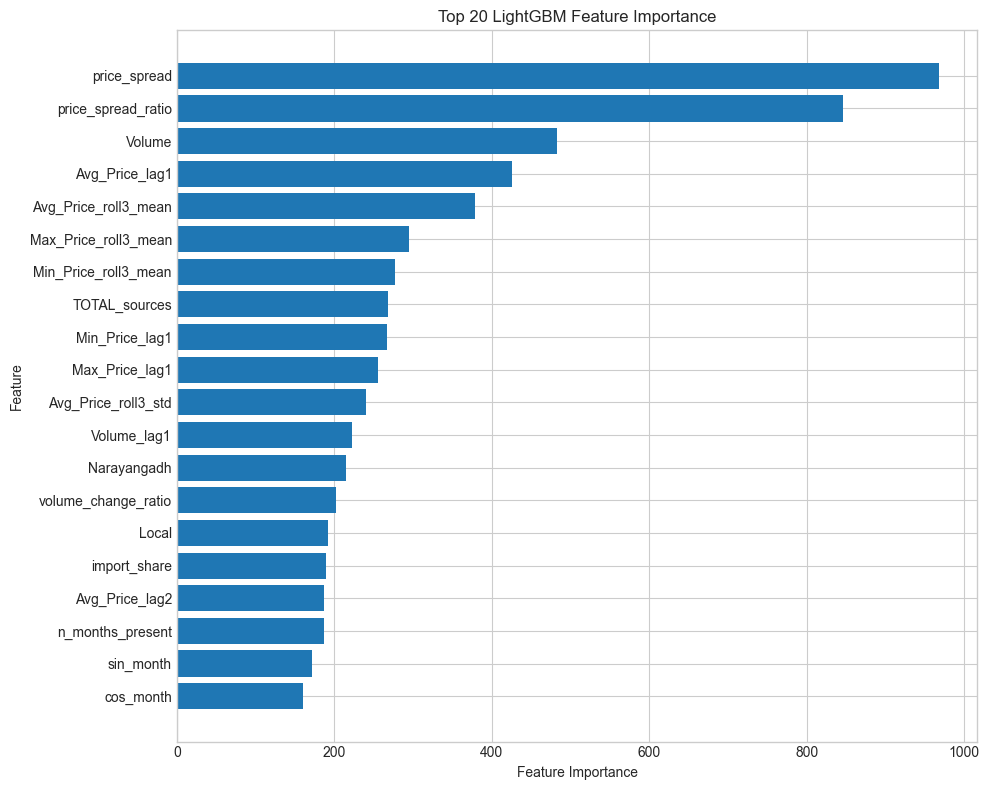

In [13]:
# LightGBM Feature Importance

lgb_model = MultiOutputRegressor(
    lgb.LGBMRegressor(**lgb_study.best_params)
)

lgb_model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": np.mean(
        [est.feature_importances_ for est in lgb_model.estimators_],
        axis=0
    )
}).sort_values("Importance", ascending=False)

print(importance.to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(
    importance["Feature"].head(20)[::-1],
    importance["Importance"].head(20)[::-1]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 LightGBM Feature Importance")
plt.tight_layout()
plt.show()

importance.to_csv("results/lightgbm_feature_importance.csv", index=False)

#### Actual vs Predicted (Validation)

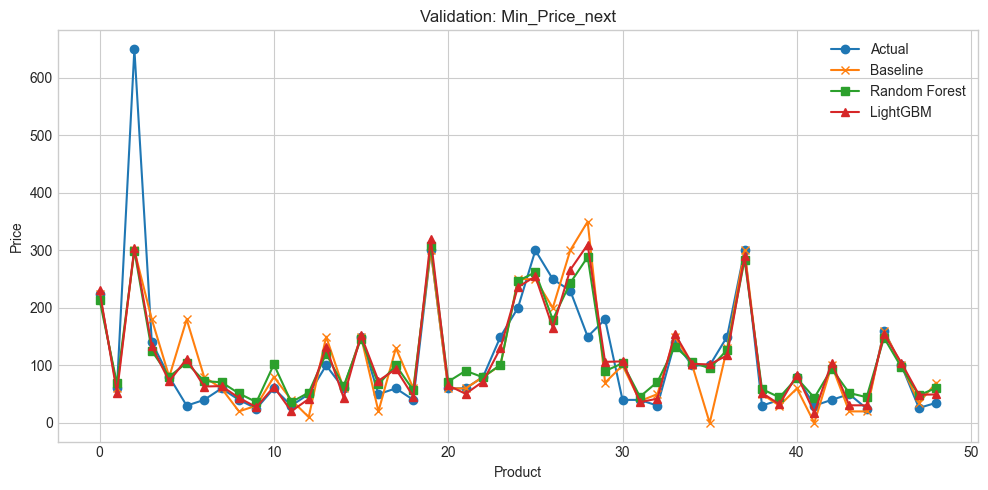

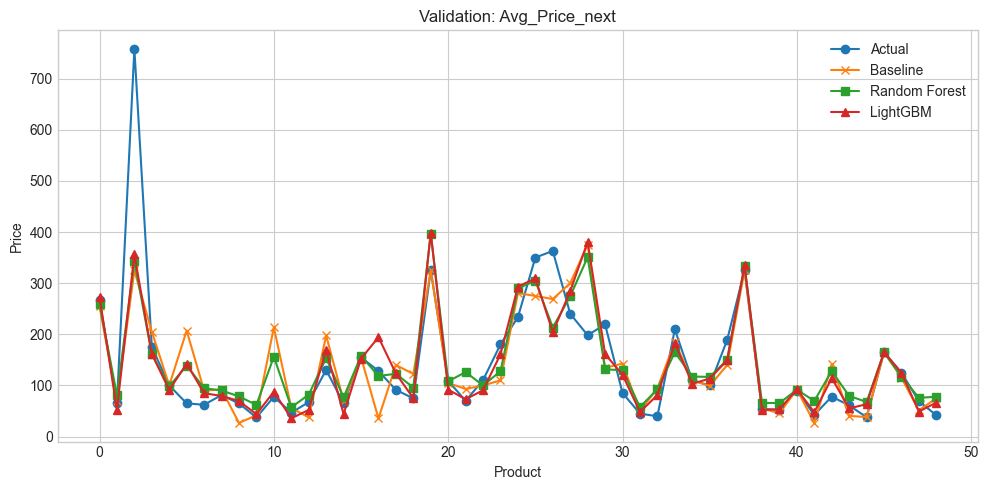

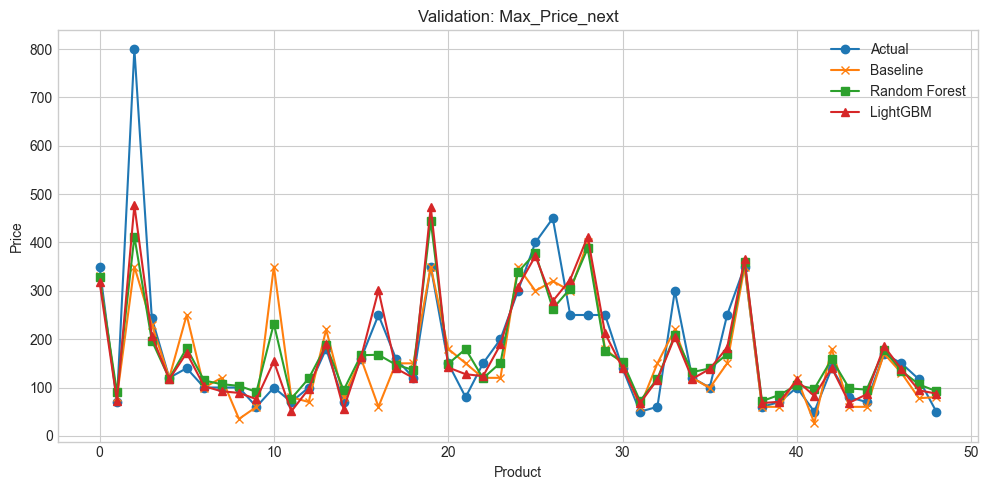

In [14]:
for i, target in enumerate(targets_next):
    plt.figure(figsize=(10, 5))
    plt.plot(y_valid.iloc[:, i].values, marker="o", label="Actual")
    plt.plot(baseline_valid[:, i], marker="x", label="Baseline")
    plt.plot(rf_valid_pred[:, i], marker="s", label="Random Forest")
    plt.plot(lgb_valid_pred[:, i], marker="^", label="LightGBM")
    plt.title(f"Validation: {target}")
    plt.xlabel("Product"); plt.ylabel("Price"); plt.legend(); plt.tight_layout()
    plt.savefig(f"plots/{target}_validation_prediction.png", dpi=300, bbox_inches="tight")
    plt.show()

In [15]:
# Ordering constraint check (Min <= Avg <= Max)
for name, pred in [("Baseline", baseline_valid), ("Random Forest", rf_valid_pred), ("LightGBM", lgb_valid_pred)]:
    violations = (pred[:, 0] > pred[:, 1]) | (pred[:, 1] > pred[:, 2])
    print(f"{name}: {violations.sum()} violations ({violations.mean() * 100:.2f}%)")

Baseline: 0 violations (0.00%)
Random Forest: 0 violations (0.00%)
LightGBM: 0 violations (0.00%)


#### Final Training (Month 1–9) & Next-Month Forecast (Per Product)
Retrain on Train + Validation (each product's own local months 1–9), then forecast
**each product's own next month** using its most recent available data. Products are
not forced onto a shared calendar month — a sparse product (e.g. only observed in
BS months 5–6) gets a forecast for its own next real month, not a fabricated month 11.


In [16]:
train_final = pd.concat([train_df, valid_df], ignore_index=True)
X_train_final = train_final[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
y_train_final = train_final[targets_next]

rf_final = MultiOutputRegressor(RandomForestRegressor(**rf_params)).fit(X_train_final, y_train_final)
lgb_final = MultiOutputRegressor(lgb.LGBMRegressor(**lgb_params)).fit(X_train_final, y_train_final)

rf_month11 = apply_constraint(rf_final.predict(X_test))
lgb_month11 = apply_constraint(lgb_final.predict(X_test))

# Baseline = last known price, taken directly from test_df (pre-fillna) so that
# products with only ONE ever observation (no real "previous month") correctly
# show as missing rather than a misleading 0.
baseline_month11 = np.column_stack([
    test_df["Min_Price_lag1"].values,
    test_df["Avg_Price_lag1"].values,
    test_df["Max_Price_lag1"].values
]).astype(float)
baseline_month11 = apply_constraint(baseline_month11)

print(f"Final training rows: {len(train_final)} | Forecast rows: {len(test_df)} "
      f"(all {test_df['Product_Name'].nunique()} products)")
print(f"Products with no baseline (single observation, no prior month): "
      f"{np.isnan(baseline_month11[:, 1]).sum()}")


Final training rows: 641 | Forecast rows: 95 (all 95 products)
Products with no baseline (single observation, no prior month): 4


#### Save Required Outputs
Two CSVs are produced beyond the validation comparison table:
- `results/month_11_forecast.csv` — final deliverable, **one row per product** (full coverage),
  each carrying its own `Last_Observed_Month_Idx` / `Forecast_Month_Idx` and a
  `n_months_present` confidence flag
- `results/validation_month_9_predictions.csv` — used by `06_Error_analysis.ipynb`


In [17]:
forecast_df = test_df[[
    "Product_Name", "Category", "calendar_month_idx", "month_name",
    "n_months_present", "is_balanced"
]].copy().reset_index(drop=True)

forecast_df = forecast_df.rename(columns={
    "calendar_month_idx": "Last_Observed_Month_Idx",
    "month_name": "Last_Observed_Month_Name",
})
forecast_df["Forecast_Month_Idx"] = forecast_df["Last_Observed_Month_Idx"] + 1

forecast_df[["Baseline_Min_Price", "Baseline_Avg_Price", "Baseline_Max_Price"]] = baseline_month11
forecast_df[["RF_Predicted_Min_Price", "RF_Predicted_Avg_Price", "RF_Predicted_Max_Price"]] = rf_month11
forecast_df[["LightGBM_Predicted_Min_Price", "LightGBM_Predicted_Avg_Price", "LightGBM_Predicted_Max_Price"]] = lgb_month11

forecast_df = forecast_df.round(2).sort_values("Product_Name").reset_index(drop=True)
forecast_df.to_csv("results/month_11_forecast.csv", index=False)

print(f"Saved: results/month_11_forecast.csv  ({len(forecast_df)} products — full coverage)")
print(f"  Full 10-month history : {(forecast_df['n_months_present'] == 10).sum()} products -> forecasting BS month 11")
print(f"  Partial history       : {(forecast_df['n_months_present'] < 10).sum()} products -> forecasting their own next month")
print(forecast_df.head(10).to_string(index=False))


Saved: results/month_11_forecast.csv  (95 products — full coverage)
  Full 10-month history : 50 products -> forecasting BS month 11
  Partial history       : 45 products -> forecasting their own next month
  Product_Name  Category  Last_Observed_Month_Idx Last_Observed_Month_Name  n_months_present  is_balanced  Forecast_Month_Idx  Baseline_Min_Price  Baseline_Avg_Price  Baseline_Max_Price  RF_Predicted_Min_Price  RF_Predicted_Avg_Price  RF_Predicted_Max_Price  LightGBM_Predicted_Min_Price  LightGBM_Predicted_Avg_Price  LightGBM_Predicted_Max_Price
Akabary_Chilly vegetable                       10                 baishakh                 5        False                  11               300.0              439.77               500.0                  311.55                  367.54                  432.53                        342.99                        409.62                        445.95
         Amala     fruit                       10                 baishakh                 9     

In [18]:
validation_results = valid_df[["Product_Name", "month_idx"]].reset_index(drop=True)
for i, target in enumerate(targets_next):
    validation_results[f"Actual_{target}"] = y_valid.iloc[:, i].values
    validation_results[f"Baseline_{target}"] = baseline_valid[:, i]
    validation_results[f"RF_{target}"] = rf_valid_pred[:, i]
    validation_results[f"LightGBM_{target}"] = lgb_valid_pred[:, i]

validation_results = validation_results.round(2)
validation_results.to_csv("results/validation_month_9_predictions.csv", index=False)

print("Saved: results/validation_month_9_predictions.csv  (used for error analysis notebook)")
print(validation_results.head(10).to_string(index=False))

Saved: results/validation_month_9_predictions.csv  (used for error analysis notebook)
      Product_Name  month_idx  Actual_Min_Price_next  Baseline_Min_Price_next  RF_Min_Price_next  LightGBM_Min_Price_next  Actual_Avg_Price_next  Baseline_Avg_Price_next  RF_Avg_Price_next  LightGBM_Avg_Price_next  Actual_Max_Price_next  Baseline_Max_Price_next  RF_Max_Price_next  LightGBM_Max_Price_next
             Apple          9                  225.0                    225.0             214.54                   230.66                 266.30                   255.00             259.75                   273.41                  350.0                    330.0             327.77                   319.22
              Arum          9                   60.0                     60.0              68.56                    52.23                  65.00                    70.00              80.70                    52.23                   70.0                     80.0              90.33                    72

In [19]:
# Validation vs Testing/Forecast — side-by-side comparison
# Validation (Month 9 -> 10): has actual values -> real error metrics
# Testing (Month 10 -> 11): forecast only, no ground truth -> summary stats only

# 1. Validation metrics (already computed: rf_valid_metrics, lgb_valid_metrics, baseline_valid_metrics)
print("VALIDATION — MONTH 9 → MONTH 10 (evaluated against actuals)")
val_summary = pd.concat([
    baseline_valid_metrics.assign(Model="Baseline"),
    rf_valid_metrics.assign(Model="Random Forest"),
    lgb_valid_metrics.assign(Model="LightGBM")
], ignore_index=True)[["Model", "Target", "MAE", "RMSE", "MAPE (%)", "R²"]]
print(val_summary.round(2).to_string(index=False))

VALIDATION — MONTH 9 → MONTH 10 (evaluated against actuals)
        Model         Target   MAE  RMSE  MAPE (%)   R²
     Baseline Min_Price_next 37.88 71.22     49.37 0.58
     Baseline Avg_Price_next 43.80 81.80     35.99 0.57
     Baseline Max_Price_next 51.47 93.16     31.22 0.52
Random Forest Min_Price_next 31.24 61.69     40.45 0.69
Random Forest Avg_Price_next 39.92 74.82     33.26 0.64
Random Forest Max_Price_next 45.28 77.70     28.99 0.67
     LightGBM Min_Price_next 29.56 61.60     34.93 0.69
     LightGBM Avg_Price_next 35.35 72.89     24.81 0.66
     LightGBM Max_Price_next 36.78 66.88     21.26 0.75


In [20]:
# 2. Next-month forecast summary (per product, no ground truth to score against)
print("\nNEXT-MONTH FORECAST — per product (no ground truth, summary of predictions only)")
test_summary = []
for i, target in enumerate(targets_next):
    test_summary.append({
        "Target": target,
        "Baseline Mean": np.nanmean(baseline_month11[:, i]), "Baseline Std": np.nanstd(baseline_month11[:, i]),
        "RF Mean": rf_month11[:, i].mean(), "RF Std": rf_month11[:, i].std(),
        "LightGBM Mean": lgb_month11[:, i].mean(), "LightGBM Std": lgb_month11[:, i].std()
    })
test_summary_df = pd.DataFrame(test_summary).round(2)
print(test_summary_df.to_string(index=False))



NEXT-MONTH FORECAST — per product (no ground truth, summary of predictions only)
        Target  Baseline Mean  Baseline Std  RF Mean  RF Std  LightGBM Mean  LightGBM Std
Min_Price_next         126.76        104.73   128.38   88.18         129.29         97.19
Avg_Price_next         156.10        122.03   153.62   98.95         153.65        109.45
Max_Price_next         192.06        149.39   181.61  109.89         179.48        117.85


In [21]:
# 3. Gap check: how far do next-month forecasts drift from the last known price (sanity check)
print("\nAvg absolute shift from Baseline (RF/LightGBM vs last known price) — next-month forecast")
for i, target in enumerate(targets_next):
    rf_shift = np.nanmean(np.abs(rf_month11[:, i] - baseline_month11[:, i]))
    lgb_shift = np.nanmean(np.abs(lgb_month11[:, i] - baseline_month11[:, i]))
    print(f"{target:18s} RF: {rf_shift:6.2f} | LightGBM: {lgb_shift:6.2f}")



Avg absolute shift from Baseline (RF/LightGBM vs last known price) — next-month forecast
Min_Price_next     RF:  18.69 | LightGBM:  22.35
Avg_Price_next     RF:  21.48 | LightGBM:  26.00
Max_Price_next     RF:  25.97 | LightGBM:  30.86


#### Final Summary

In [22]:
print("FINAL SUMMARY")
print("Training       : each product's own local months 1-8")
print("Validation     : each product's own local month 9 -> local month 10")
print("Final Training : each product's own local months 1-9")
print("Forecast Input : each product's own last observed row -> its own next month")
print(f"\nFull product coverage in forecast: {forecast_df['Product_Name'].nunique()} / {df['Product_Name'].nunique()}")

print(f"\nRF Best Validation RMSE      : {rf_study.best_value:.3f}")
print(f"LightGBM Best Validation RMSE: {lgb_study.best_value:.3f}")

print("\nFiles saved in results/:")
print(" - baseline_vs_rf_vs_lightgbm_validation.csv")
print(" - validation_month_9_predictions.csv  (-> used in 06_Error_analysis.ipynb)")
print(" - month_11_forecast.csv               (-> final deliverable, full product coverage)")
print("\n✓ COMPLETE MULTI-TARGET PRICE FORECASTING PIPELINE FINISHED")


FINAL SUMMARY
Training       : each product's own local months 1-8
Validation     : each product's own local month 9 -> local month 10
Final Training : each product's own local months 1-9
Forecast Input : each product's own last observed row -> its own next month

Full product coverage in forecast: 95 / 95

RF Best Validation RMSE      : 71.402
LightGBM Best Validation RMSE: 67.124

Files saved in results/:
 - baseline_vs_rf_vs_lightgbm_validation.csv
 - validation_month_9_predictions.csv  (-> used in 06_Error_analysis.ipynb)
 - month_11_forecast.csv               (-> final deliverable, full product coverage)

✓ COMPLETE MULTI-TARGET PRICE FORECASTING PIPELINE FINISHED
